<a href="https://colab.research.google.com/github/LaimengEung/inf-604-data-analysis-i-repo/blob/master/Copy_of_Lab6_Hypothesis_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TP6 - Hypothesis Testing**

**Course**: **INF-604: Data Analysis** <br>
**Lecturer**: **Sothea HAS, PhD**

-----

**Objective:** In this lab, you will use hypothesis testing to analyze real-world problems and datasets. By the end, you will be able to identify when to apply a $z$-test or a $t$-test and understand the limitations of both methods in practical scenarios.


- You can work directly with `Google Colab` here: [Lab6_Hypothesis_Testing.ipynb](https://colab.research.google.com/drive/1QC3OVQNqOGRZwWGt7ozQvmQnR633w54v?usp=sharing).


-----


# **1. Normal Distribution**

**a.** A random variable $X$ follows a normal distribution with $\mu=7.2$ and $\sigma=1.75$. Calculate the following probabilities:

- $\mathbb{P}(X\leq 9)$
- $\mathbb{P}(X\geq 6)$
- $\mathbb{P}(6\leq X < 9)$
- $\mathbb{P}(|X|\geq 10)$
- $\mathbb{P}(|X|> 5)$
- Find $z_0$ such that $\mathbb{P}(X\geq z_0)=0.95$
- Find $z_0$ such that $\mathbb{P}(X\leq z_0)=0.95$
- Find $z_0$ such that $\mathbb{P}(|X|\geq z_0)=0.025$

In [1]:
import numpy as np
import scipy.stats as stats

In [ ]:
# To do
dist = stats
dir(dist)

In [2]:
dist = stats.norm(loc=7.2, scale=1.75)


> - loc: location parameter | shifts the dist left/right -> it happens to be the **mean** for normal<br>
> - scale: scale of a distribution | stretches/squishes the dist -> happens to be the **std** for normal<br>
> - Why not just call mean and std?: It helps to have a more generalized concept cuz not every distribution has a mean.<br>

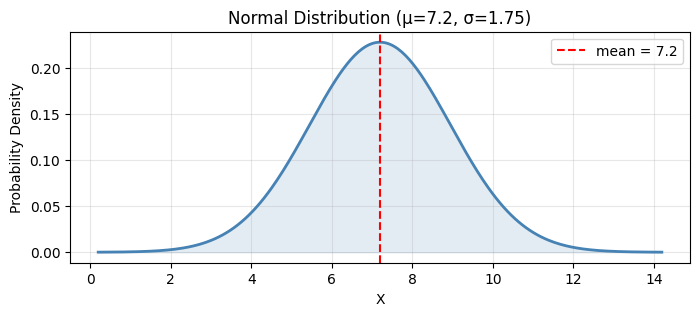

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Define distribution
loc, scale = 7.2, 1.75
# loc, scale = 0, 1
dist = stats.norm(loc=loc, scale=scale)

# Generate x range (±4 std devs is more than enough)
x = np.linspace(loc - 4*scale, loc + 4*scale, 300)
# print(x[-10])
# Plot PDF
plt.figure(figsize=(8, 3))
# plt.plot(x, color='steelblue', linewidth=2)   if we only plot x (so from 0 to 299), it will plots the indices, not the values of x 
plt.plot(x, dist.pdf(x), color='steelblue', linewidth=2)
plt.axvline(loc, color='red', linestyle='--', label=f'mean = {loc}')   # adds a vertical line 
plt.fill_between(x, dist.pdf(x), alpha=0.15, color='steelblue')        # fills the area between the specified range

plt.title(f'Normal Distribution (μ={loc}, σ={scale})')
plt.xlabel('X')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- $\mathbb{P}$: probability function/operator
- ${X}$: random variable
- ${Z}$: standardized random variable (z-variable)
- ${z_0}$: a cut-off, basically a constant

In [5]:
dist = stats.norm(loc=7.2, scale=1.75)
# without specifying loc and scale, stats.norm uses defaults (loc=0, scale=1)

# Left tail (Cumulative Distribution Function; cdf)
cdf_9 = dist.cdf(9)

# Right tail (Survival Function; sf) (can also do 1 - cdf(6))
sf_6 = dist.sf(6)

# Between: cdf(90) - cdf(6)
between_6_9 = dist.cdf(9) - dist.cdf(6)

# Two-Tail (absolute value of X) (cdf(left-tail) + sf(right-tail))
absolute_10 = dist.cdf(-10) + dist.sf(10) 
# can see from the graph, cdf(-10) is basically nothing...
absolute_5 = dist.cdf(-5) + dist.sf(5)

# Find z_0 such that: (inverse CDF)
# (Probability Point Function; ppf: Inverse CDF): It maps the given probability (p) to the corresponding value (x)
# X >= z_0 = 0.95
z_0_rt = dist.ppf(1 - 0.95) 
    # we want to find what over z_0 has proability of 0.95
    # (1 - cdf(z_0)) = sf(z_0) would give 0.95
    # Hence, z_0 greater than p = 1-0.95 (0.05), would give us 0.95

# X <= z_0 = 0.95
z_0_lt = dist.ppf(0.95)

# |X| >= z_0 = 0.025 
    # since the center is not 0 (mean=7.2), we cannot just dist.ppf(1 - (0.025/2)) 
    # meaning that P(X <= -z_0) != P(X >= z_0)
        # as can see from the graph, P(X<=0) is practically 0, let alone negative values
    # in this case, we can use brentq (Brent's root-finding method)
from scipy.optimize import brentq
# brenq(f: fn, a, b); a and b: bracket endpoints (lower and upper x-values) must have opposite sign (one neg, one pos)
def two_tail_equation(z, p):
    left_tail = dist.cdf(-z)
    right_tail = dist.sf(z)
    return left_tail + right_tail - p

z_0_tt = brentq(two_tail_equation, 0, 15, args=(0.025))    # we set a=0, b=15, since the endpoints in the graph seems to cutoff from these two values
# orrrrrrr, we can just ignore the left tail (too weak to consider), so just do dist.ppf(1-0.025)
z_0_tt = dist.ppf(1 - 0.025)

In [6]:
results = {
    "P(X <= 9)": cdf_9,
    "P(X >= 6)": sf_6,
    "P(6 <= X < 9)": between_6_9,
    "P(|X| >= 10)": absolute_10,
    "P(|X| > 5)": absolute_5,
    "z_0 for P(X >= z_0)=0.95": z_0_rt,
    "z_0 for P(X <= z_0)=0.95": z_0_lt,
    "z_0 for P(|X| >= z_0)=0.025": z_0_tt,
}

for label, value in results.items():
    if "z_0" in label:
        print(f"{label:<30} = {value:.4f}") # :<30 : left-align is a field width of 30 chars
    else:
        print(f"{label:<30} = {value:.4f}  ({value*100:.2f}%)")

P(X <= 9)                      = 0.8482  (84.82%)
P(X >= 6)                      = 0.7536  (75.36%)
P(6 <= X < 9)                  = 0.6017  (60.17%)
P(|X| >= 10)                   = 0.0548  (5.48%)
P(|X| > 5)                     = 0.8956  (89.56%)
z_0 for P(X >= z_0)=0.95       = 4.3215
z_0 for P(X <= z_0)=0.95       = 10.0785
z_0 for P(|X| >= z_0)=0.025    = 10.6299


**b.** Assume that the waist sizes for medium (M) jeans sold in a store are normally distributed with a mean size of 31 inches and a standard deviation of 1 inch, i.e., $X\sim{\cal N}(31, 1)$. Find the probability that a randomly selected pair of size M jeans has a waist size:

- Less than 30 inches.
- Greater than 32 inches.
- Suppose you bought a pair of size M jeans, and your comfortable waist size is between 30.5 and 31.5 inches. What's the probability that your new jeans fit comfortably?

In [7]:
# µ = 31, σ² = 1
mu, sigma = 31, 1
dist = stats.norm(loc=mu, scale=sigma)

# Find probability that a randomly selected pair of size M jeans
# 1. Less than 30 inches
under_30 = dist.cdf(30)

# 2. Greater than 32 inces
over_32 = dist.sf(32)

# 3. between 30.5 and 31.5
between_tt = dist.cdf(31.5) - dist.cdf(30.5)

In [8]:
results = {
    'Less than 30 inches': under_30,
    'Greater than 32 inches': over_32,
    'Between 30.5 and 31.5 inches': between_tt
}

print(f"With mean of {mu} and std of {sigma},\nthe probability that a randomly selected pair of size M jeans is")
for label, result in results.items():
    print(f"{label:<30} = {result:.4f}")

With mean of 31 and std of 1,
the probability that a randomly selected pair of size M jeans is
Less than 30 inches            = 0.1587
Greater than 32 inches         = 0.1587
Between 30.5 and 31.5 inches   = 0.3829


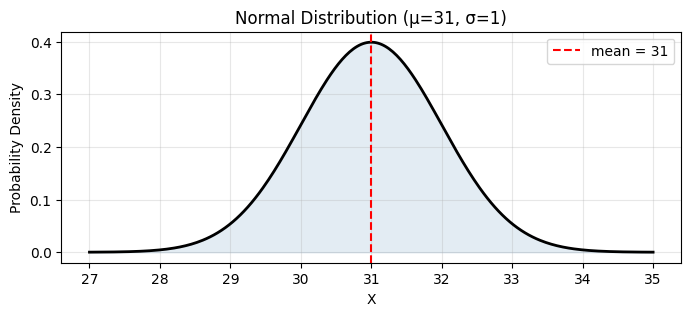

In [131]:
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)

plt.figure(figsize=(8,3))
plt.plot(x, dist.pdf(x), color='black', linewidth=2)
plt.axvline(mu, color='red', linestyle='--', label=f'mean = {mu}')
plt.fill_between(x, dist.pdf(x), alpha=0.15, color='steelblue')

plt.title(f'Normal Distribution (μ={mu}, σ={sigma})')
plt.xlabel('X')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **2. $z$-test and $t$-test**

The Z-Test Formula$$z = \frac{\bar{x} - \mu}{\frac{\sigma}{\sqrt{n}}}$$
The One-Sample T-Test Formula$$t = \frac{\bar{x} - \mu}{\frac{s}{\sqrt{n}}}$$

**a.** When conducting a hypothesis test to check the means of samples, if the population standard deviation is known, we can use a **Z-Test** When the population standard deviation is unknown, we use a **T-Test**.

**b.** How can you tell if a hypothesis test should be one-tailed or two-tailed?
> One-tailed: use when the claim has a direction
> - Right-tailed: testing an increase   $(H_1: \mu > \mu_0)$
> - Left-tailed: testing a decrease     $(H_1: \mu < \mu_0)$
>
> Two-tailed: use when the claim is just different (no direction) $(H_1: \mu \neq \mu_0)$

**c.** Resting heart rate is known to be 71 beats per minute on average, with a standard deviation of 4 beats per minute. A set of researchers believe that heart rate will increase in men when they are waiting to go in to a job interview. To test this hypothesis, a group of 9 men attending job interviews are fitted with a wireless heart rate monitor to wear on their chest in the hour preceding their interviews. Their average heart rates over this hour are shown in the table below.

| Participant | Heart rate (bmp) |
|-------------|-------------------|
| 1           | 80               |
| 2           | 74               |
| 3           | 73               |
| 4           | 72               |
| 5           | 78               |
| 6           | 75               |
| 7           | 70               |
| 8           | 74               |
| 9           | 69               |


- Visulize the distribution of the heart rate data. You can assume that it's normally distributed.
- Should a $z$-test or a $t$-test be used to check if there is significant evidence to suggest heart rate increases in men while they are waiting to attend a job interview?
- Conduct the test at the 5% level and interpret your result by assuming that the data is normally distributed.

<Axes: xlabel='Heart rate', ylabel='Count'>

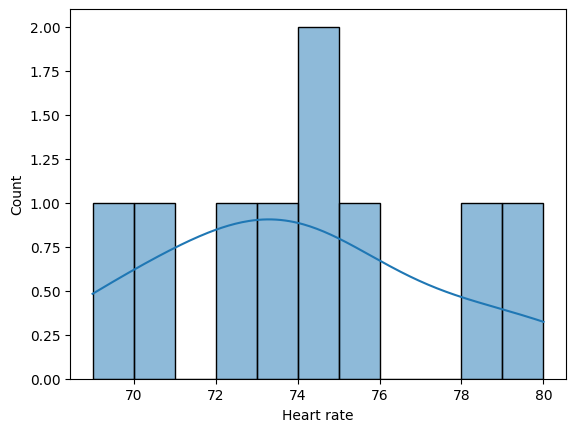

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
data = pd.DataFrame({
    'Heart rate' : [80, 74, 73, 72, 78, 75, 70, 74, 69]
})
data
sns.histplot(data, x='Heart rate', binwidth=1, kde=True)

> z-test should be used because the data can be assumed to be normal with known standard deviation to be 4.

Right-tailed z-test

$H_0: \text{Average Heart Rate} = 71$\
$H_1: \text{Average Heart Rate} > 71$

For significance level $\alpha = 0.05$, compute $z_\alpha$ such that $\mathbb{P}(Z \ge z_\alpha) = \alpha$\
Since $\alpha = 0.05$, we use <code>stats.norm.ppf(0.95)</code> $=> z_\alpha \approx 1.645$

Decision:
- If $Z \ge 1.645$, we reject $H_0$ with confidence level 0.95
- If $Z < 1.645$, we CANNOT reject $H_0$ due to insufficient evidence.

In [ ]:
# Conduct the test at the 5% level
# we can use the default stats.norm (0, 1)
heart_rate = [80, 74, 73, 72, 78, 75, 70, 74, 69]
mu, sigma = 71, 4

x_bar = np.mean(heart_rate)
z_stat = (x_bar - mu) / (sigma / np.sqrt(len(heart_rate)))   # Observed value
z_alpha = stats.norm.ppf(0.95)                               # Critical value

print(f"Observed Vaue (Z): {z_stat:.3f}")
print(f"Critical Value (z_alpha): {z_alpha:.3f}")
print("Decision:", "Reject H_0" if z_stat >= z_alpha else "Fail to Reject H_0")

Observed Vaue (Z): 2.167
Critical Value (z_alpha): 1.645
Decision: Reject H_0


> Since $Z = 2.167 > 1.645$, we have sufficient evidence to reject $H_0$\
> Hence, with a confidence level of 0.95, we can conclude that there is **significant evidence** to suggest that heart rate does indeed increase in men while they are waiting to attend a job interview.

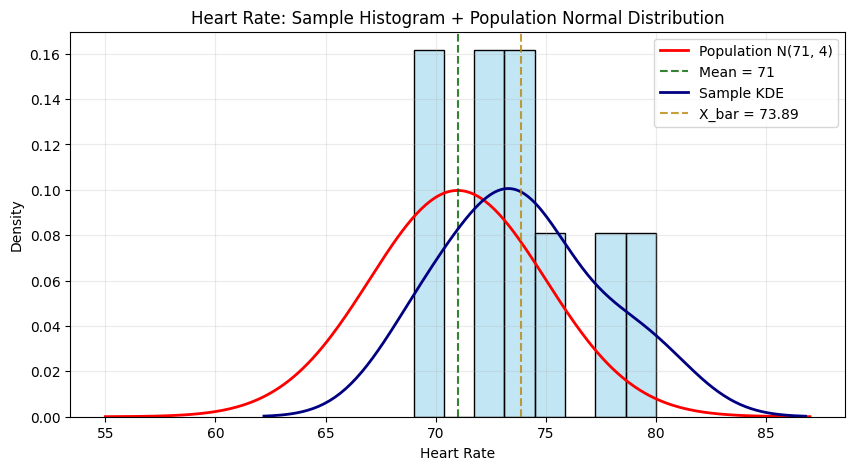

In [79]:
from scipy.stats import norm

# Data
heart_rate = [80, 74, 73, 72, 78, 75, 70, 74, 69]
mu, sigma = 71, 4
dist = norm(loc=mu, scale=sigma)

plt.figure(figsize=(10, 5))

# Population Plot
x_pop = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
plt.plot(x_pop, dist.pdf(x_pop), color='red', linewidth=2, label='Population N(71, 4)')
plt.axvline(mu, color='darkgreen', alpha=0.8, linestyle='--', label=f'Mean = {mu}')

# Sample Plot (KDE)
sns.kdeplot(heart_rate, color='navy', linewidth=2, label='Sample KDE')

# Sample Histogram
sns.histplot(heart_rate, color='skyblue', stat='density', bins=8, alpha=0.5)
plt.axvline(x_bar, color='darkgoldenrod', alpha=0.8, linestyle='--', label=f'X_bar = {x_bar:.2f}')

plt.title("Heart Rate: Sample Histogram + Population Normal Distribution")
plt.xlabel("Heart Rate")
plt.ylabel("Density")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

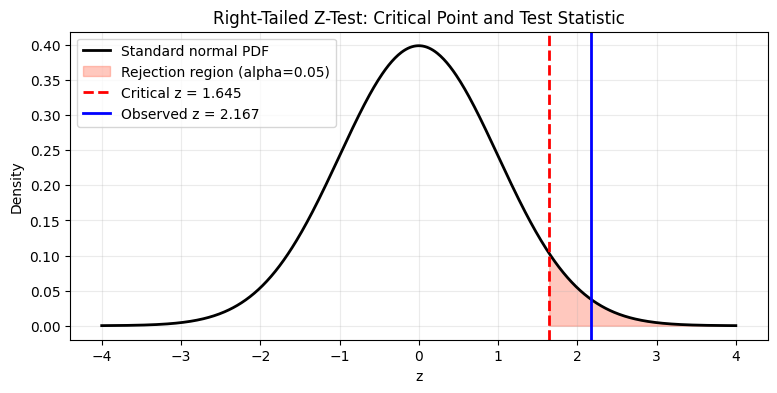

z_stat = 2.167, z_alpha = 1.645
Decision: Reject H0


In [84]:
# Standard normal curve
z = np.linspace(-4, 4, 600)
pdf = norm.pdf(z)

plt.figure(figsize=(9, 4))
plt.plot(z, pdf, color="black", lw=2, label="Standard normal PDF")

# Shade rejection region (right tail)
z_rej = np.linspace(z_alpha, 4, 200)
plt.fill_between(z_rej, norm.pdf(z_rej), color="tomato", alpha=0.35, label="Rejection region (alpha=0.05)")

# Critical line and observed test-stat line
plt.axvline(z_alpha, color="red", ls="--", lw=2, label=f"Critical z = {z_alpha:.3f}")
plt.axvline(z_stat, color="blue", ls="-", lw=2, label=f"Observed z = {z_stat:.3f}")

plt.title("Right-Tailed Z-Test: Critical Point and Test Statistic")
plt.xlabel("z")
plt.ylabel("Density")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(f"z_stat = {z_stat:.3f}, z_alpha = {z_alpha:.3f}")
print("Decision:", "Reject H0" if z_stat >= z_alpha else "Fail to reject H0")

The Z-Test Formula$$z = \frac{\bar{x} - \mu}{\frac{\sigma}{\sqrt{n}}}$$
The One-Sample T-Test Formula$$t = \frac{\bar{x} - \mu}{\frac{s}{\sqrt{n}}}$$

**d.** A psychology student, Sarah, is giving out sleep diaries to her university friends to monitor the number of hours of sleep they have each night. Sarah believes that university students sleep for 6 hours per night on average. Below is the data that they collected. The number of hours sleep per night for each student was averaged over a one month monitoring period. Is there any evidence to suggest that Sarah's belief is incorrect (you should visualize the distribution of the data first)?

| Participant | Hours of sleep per night |
|-------------|--------------------------|
| 1           | 7.2                      |
| 2           | 8.7                      |
| 3           | 5.4                      |
| 4           | 6.1                      |
| 5           | 5.6                      |
| 6           | 6.7                      |
| 7           | 5.9                      |
| 8           | 6.3                      |
| 9           | 7                        |
| 10          | 4.2                      |


Claim: Average Sleep is 6 hours\
Question: Whether the claim is incorrect (Two-tailed)

$H_0: \mu = 6$\
$H_1: \mu \neq 6$

Since population std is unknown, and sample size is smaller than 30, we'll compute using a **t-test**

In [95]:
sleep_hours = [7.2, 8.7, 5.4, 6.1, 5.6, 6.7, 5.9, 6.3, 7, 4.2]
mu = 6
x_bar = np.mean(sleep_hours)
std = np.std(sleep_hours, ddof=1)   # don't forget degree of freedom (Delta dof = 1)
n = len(sleep_hours)
t = (x_bar - mu) / (std / np.sqrt(n))
t

np.float64(0.811646881574848)

In [96]:
t_stat, p_value = stats.ttest_1samp(sleep_hours, popmean=mu)
print(t_stat, p_value)

0.811646881574848 0.43793283367461433


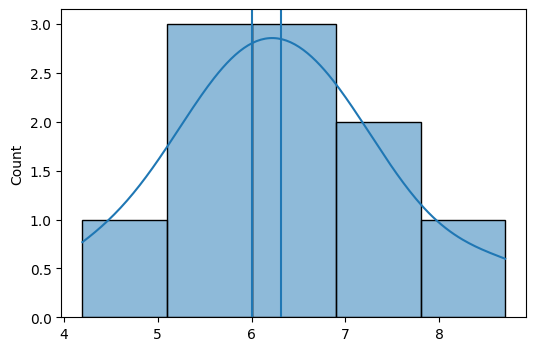

In [94]:
plt.figure(figsize=(6,4))

# plt.plot()
sns.histplot(sleep_hours, kde=True)
plt.axvline(x_bar)
plt.axvline(mu)

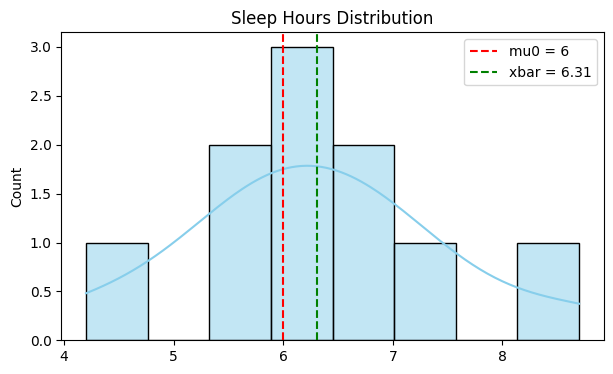

xbar = 6.3100000000000005
s (sample std) = 1.2077987323133674
t_stat = 0.811646881574848
p_value = 0.43793283367461433
Fail to reject H0: insufficient evidence that mean sleep differs from 6.


In [97]:
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

sleep_hours = np.array([7.2, 8.7, 5.4, 6.1, 5.6, 6.7, 5.9, 6.3, 7.0, 4.2])
mu0 = 6
alpha = 0.05

# quick visualization
plt.figure(figsize=(7,4))
sns.histplot(sleep_hours, kde=True, bins=8, color="skyblue")
plt.axvline(mu0, color="red", linestyle="--", label="mu0 = 6")
plt.axvline(sleep_hours.mean(), color="green", linestyle="--", label=f"xbar = {sleep_hours.mean():.2f}")
plt.legend()
plt.title("Sleep Hours Distribution")
plt.show()

# one-sample t-test (two-sided by default)
t_stat, p_value = stats.ttest_1samp(sleep_hours, popmean=mu0)

print("xbar =", sleep_hours.mean())
print("s (sample std) =", np.std(sleep_hours, ddof=1))
print("t_stat =", t_stat)
print("p_value =", p_value)

if p_value < alpha:
    print("Reject H0: evidence suggests mean sleep is different from 6.")
else:
    print("Fail to reject H0: insufficient evidence that mean sleep differs from 6.")

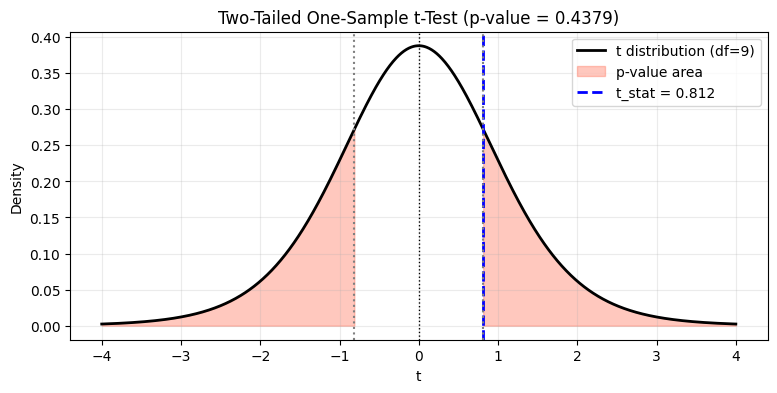

t_stat = 0.8116
p_value = 0.4379


In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Data and test
sleep_hours = np.array([7.2, 8.7, 5.4, 6.1, 5.6, 6.7, 5.9, 6.3, 7.0, 4.2])
mu0 = 6
t_stat, p_value = stats.ttest_1samp(sleep_hours, popmean=mu0)  # two-sided by default
df = len(sleep_hours) - 1

# t distribution
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)

plt.figure(figsize=(9, 4))
plt.plot(x, y, color="black", lw=2, label=f"t distribution (df={df})")

# Shade two-tailed p-value region: |T| >= |t_stat|
t_abs = abs(t_stat)

x_left = x[x <= -t_abs]
x_right = x[x >= t_abs]
plt.fill_between(x_left, stats.t.pdf(x_left, df), color="tomato", alpha=0.35, label="p-value area")
plt.fill_between(x_right, stats.t.pdf(x_right, df), color="tomato", alpha=0.35)

# Mark observed t-stat and center
plt.axvline(t_stat, color="blue", ls="--", lw=2, label=f"t_stat = {t_stat:.3f}")
plt.axvline(-t_abs, color="gray", ls=":", lw=1.5)
plt.axvline(t_abs, color="gray", ls=":", lw=1.5)
plt.axvline(0, color="black", ls=":", lw=1)

plt.title(f"Two-Tailed One-Sample t-Test (p-value = {p_value:.4f})")
plt.xlabel("t")
plt.ylabel("Density")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(f"t_stat = {t_stat:.4f}")
print(f"p_value = {p_value:.4f}")

# Further readings
- [T-test vs. Z-test, DataCamp](https://www.datacamp.com/tutorial/t-test-vs-z-test)
- [Standard normal table, wikipedia](https://en.wikipedia.org/wiki/Standard_normal_table).
- [T-distribution table](https://www.tdistributiontable.com/).